# 01 — Market data

Download, inspect, and clean historical prices for the example portfolio:

- AAPL 30%, MSFT 25%, GOOGL 20%, SPY 25%
- Period: 2020-01-01 → 2026-09-01
- Benchmark: S&P 500 (`^GSPC`)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from data.cleaning import clean_price_frame
from data.config import DEFAULT_BENCHMARK, DEFAULT_END, DEFAULT_START, DEFAULT_TICKERS
from data.loader import download_prices, load_prices, save_raw_and_processed

In [2]:
processed_path = ROOT / "data" / "processed" / "prices.csv"

if processed_path.exists():
    raw_prices = load_prices(processed_path)
else:
    raw_prices = download_prices(DEFAULT_TICKERS, DEFAULT_START, DEFAULT_END)

raw_prices.head()

,AAPL,MSFT,GOOGL,SPY
date,,,,
2020-01-02,72.271568,151.544250,67.788933,295.391724
2020-01-03,71.568901,149.657318,67.434296,293.155029
2020-01-06,72.139191,150.044098,69.231720,294.273468
2020-01-07,71.799927,148.676025,69.097984,293.445923
2020-01-08,72.954926,151.044174,69.589821,295.009979


In [3]:
print(raw_prices.shape)
print(raw_prices.index.min(), "→", raw_prices.index.max())
raw_prices.isna().sum()

(1674, 4)
2020-01-02 00:00:00 → 2026-08-31 00:00:00


AAPL     0
MSFT     0
GOOGL    0
SPY      0
dtype: int64

In [4]:
prices = clean_price_frame(raw_prices)
save_raw_and_processed(prices)
prices.tail()

,AAPL,MSFT,GOOGL,SPY
date,,,,
2026-08-25,309.899994,491.709991,346.737122,764.012756
2026-08-26,313.450012,496.369995,341.780304,764.182373
2026-08-27,314.579987,505.059998,340.431183,769.189941
2026-08-28,319.700012,513.530029,346.367371,767.444275
2026-08-31,316.850006,507.290009,339.132019,765.149963


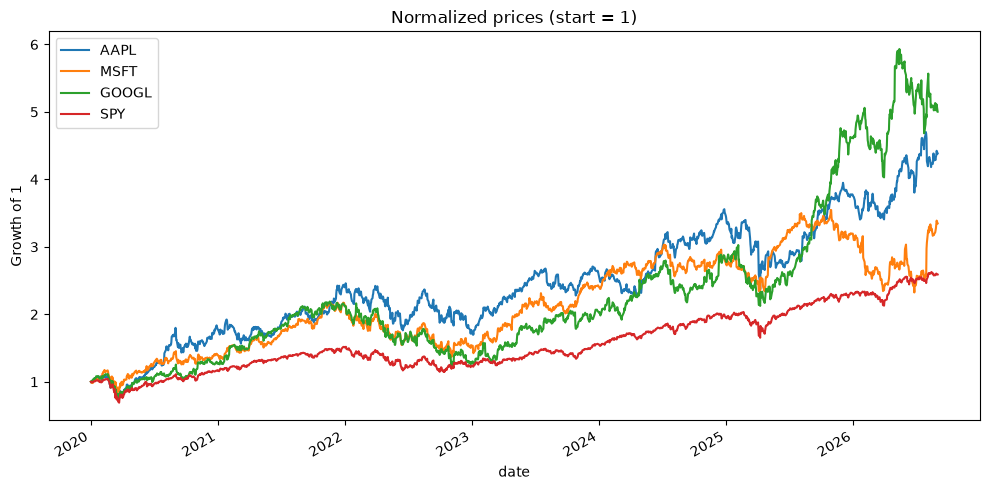

In [5]:
normalized = prices / prices.iloc[0]
ax = normalized.plot(figsize=(10, 5), title="Normalized prices (start = 1)")
ax.set_ylabel("Growth of 1")
plt.tight_layout()

In [6]:
benchmark = download_prices([DEFAULT_BENCHMARK], DEFAULT_START, DEFAULT_END)
benchmark = clean_price_frame(benchmark)
benchmark.head()

Ticker,^GSPC
date,
2020-01-02,3257.850098
2020-01-03,3234.850098
2020-01-06,3246.280029
2020-01-07,3237.179932
2020-01-08,3253.050049
